In [27]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
from functools import partial
import re

# Plotting
import matplotlib.pyplot as plt

In [28]:
# Define lat/lon ranges and region name for entire notebook
lat_start, lat_end = input("Enter latitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lat_range = (int(lat_start), int(lat_end))

lon_start, lon_end = input("Enter longitude range with each integer value separated by a comma. Do not use spaces or any other characters. If entire globe desired, enter '0,0'.") \
    .split(',')
lon_range = (int(lon_start), int(lon_end))

region = input("Which region do these ranges correspond to? If entire globe, enter nothing.")

In [29]:
def get_run_num(path):
    """
    function that extracts the exact number from the folder name so python won't sort it like 1, 10... but as 1, 2... 
    """
    # using regex to extract the number
    match = re.search(r'(\d+)$', path.name)
    # returning number as int (if match exists) --> this will help to sort it correctly 
    return int(match.group(1)) if match else 0

In [30]:
def load_nc_tryinglatlonrange(do_mean, abs_val, lat_range=lat_range, lon_range=lon_range):

    # A flag to take the mean or not (different types of variable importance, IG completeness property)
    do_mean = do_mean.lower().strip()

    # A flag to take abs val or not for different ways of interpreting variable importance
    abs_val = abs_val.lower().strip()


    # getting directory for the result batches nc files 
    parent_dir = Path.cwd() / "climate_experiments" 

    # initializing dictionary for folder file counts to ensure each folder (differentiated as folder paths) has same number of folder items 
    folder_file_counts = {}

    # going thru directory to find any folders that start with result_batches (by the glob) & going thru it alphabetically (by the sorted)
    for run_folder in sorted(parent_dir.glob("result_batches*"), key=get_run_num):
        # is_dir() to ensure that result_batches is actually a folder, not like a nc file or something idk 
        if run_folder.is_dir():
            # turning all the nc files in that folder into a list 
            nc_files = list(run_folder.glob("*.nc"))
            # if there are actually files in the folder
            if nc_files: 
                # count number of files in the folder and store that in the dictionary
                folder_file_counts[run_folder] = len(nc_files)

    # error handling if all the folders are empty 
    if not folder_file_counts:
        raise ValueError("no nc files in the folder!")


    # finding max number of file counts (should be 56/57) -- complete run length
    dynamic_expected = max(folder_file_counts.values())
    print(f"max is {dynamic_expected} files")


    # initializie list that will hold the arrays from every run 
    all_runs_data = []

    # going through each folder and looking at the files and the count of the files in the folder
    for run_folder in sorted(folder_file_counts.keys(), key=get_run_num):
        count = folder_file_counts[run_folder]

        # if the count of the files in the run folder does not equal 56/57 
        if count != dynamic_expected:
            print(f"skip{run_folder.name} bc only {count} files, expected {dynamic_expected}")
            # keep going to the next folder and don't save the folder that doesn't have right amount of files 
            continue
        
        # saving the nc files in chrnological order (via sorted)
        nc_files = sorted(list(run_folder.glob("*.nc")))

        
        # opening the files in the folder
            # concat_dim = yr_combo --> creates new dimension to stack all the arrays tg 
            # combine = nested --> just stack in the order that files are alr in since alr sorted (computationally more efficient)
        
        # ----------------------- If lat, lon given are None ---------------------------------------
        # with no lat/lon ranges:
        if lat_range == (0,0) and lon_range == (0,0) :

            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', combine='nested')
        

        # ----------------------- If lat/lon range given ---------------------------------------
        else:

            def _preprocess(x, lon_bnds, lat_bnds):
                return x.sel(lon=slice(*lon_bnds), lat=slice(*lat_bnds))

            partial_func = partial(_preprocess, lon_bnds=lon_range, lat_bnds=lat_range)
            
            run_ds = xr.open_mfdataset(nc_files, concat_dim='yr_combo', preprocess=partial_func, combine='nested') 
 

        # extracting integrated gradient maps from nc file
        run_data = run_ds['ig_heatmaps'].values
            # run_data shape --> (56, 25, 144, 73, 6)
        
        
        # ----------------------- If do mean flag on ---------------------------------------
        if do_mean == 'yes':
                
                run_mean_samples = np.nanmean(np.abs(run_data), axis=1, dtype=np.float64) if abs_val == 'yes' else np.nanmean(run_data, axis=1, dtype=np.float64)

                # appending to list 
                # debug folder loading order
                print(f"folder: {run_folder.name}")
                all_runs_data.append(run_mean_samples)
              

        # ----------------------- If do mean flag off ---------------------------------------
        elif do_mean == 'no':


            # debug folder loading order 
            print(f"folder: {run_folder.name}") 
            all_runs_data.append(run_data)


        # --------------------- If flag entered improperly -----------------------------------
        else:
            raise ValueError("Enter yes or no for each flag.") 


    # error handling if all folders do not have enough items 
    if not all_runs_data:
        raise ValueError("none of the folders have enough nc files")

    # stacking all the averaged heatmaps 
    return np.stack(all_runs_data)

In [31]:
completeness_property_phi_matrix = load_nc_tryinglatlonrange(do_mean='no', abs_val='no')
print(completeness_property_phi_matrix.shape)

max is 56 files
folder: result_batchescarolinekranefuss_1
folder: result_batchessophiekim_1
(2, 56, 25, 144, 73, 6)


In [32]:
parent_dir = Path.cwd() / "climate_experiments"

#### **delta prediction calculation**

In [33]:
# initialize list that will hold the delta values
delta_data = []

# go thru the run folders --> track the index of the run folder
for run_idx, run_folder in enumerate(sorted(parent_dir.glob("result_batches*"), key=get_run_num)):
    print(f"processing run index {run_idx} (aka folder: {run_folder.name})")

    # go thru each file and track the file index 
    for file_idx, file in enumerate(sorted(list(run_folder.glob("*.nc")))):
        print(f"  -> processing file index {file_idx} (aka file: {file.name})")
        # open 
        ds = xr.open_dataset(file)
        # calculate the delta predictions (25 for each file)
        delta = (ds['y_pred'].values - ds['exact_baseline_prediction'].values)
        # print(delta.shape) # (25,)
    
        # go thru each sample idx and append to the id column
        for sample_idx in range(len(delta)):
            delta_data.append({
                'id': f"{run_idx}_{file_idx}_{sample_idx}",
                'delta': delta[sample_idx]
            })
        ds.close()

# make dataframe 
delta_df = pd.DataFrame(delta_data)

processing run index 0 (aka folder: result_batchescarolinekranefuss_1)
  -> processing file index 0 (aka file: res_ssp119_2015_2025.nc)
  -> processing file index 1 (aka file: res_ssp119_2015_2035.nc)
  -> processing file index 2 (aka file: res_ssp119_2015_2045.nc)
  -> processing file index 3 (aka file: res_ssp119_2015_2055.nc)
  -> processing file index 4 (aka file: res_ssp119_2015_2065.nc)
  -> processing file index 5 (aka file: res_ssp119_2015_2075.nc)
  -> processing file index 6 (aka file: res_ssp119_2015_2085.nc)
  -> processing file index 7 (aka file: res_ssp119_2025_2035.nc)
  -> processing file index 8 (aka file: res_ssp119_2025_2045.nc)
  -> processing file index 9 (aka file: res_ssp119_2025_2055.nc)
  -> processing file index 10 (aka file: res_ssp119_2025_2065.nc)
  -> processing file index 11 (aka file: res_ssp119_2025_2075.nc)
  -> processing file index 12 (aka file: res_ssp119_2025_2085.nc)
  -> processing file index 13 (aka file: res_ssp119_2035_2045.nc)
  -> processing

In [58]:
delta_df['delta'].dtype

dtype('float32')

(array([ 17.,  40.,  58., 116., 398., 930., 258., 232., 400., 351.]),
 array([-0.99926865, -0.80138201, -0.60349542, -0.40560877, -0.20772214,
        -0.00983551,  0.18805112,  0.38593775,  0.5838244 ,  0.78171098,
         0.97959763]),
 <BarContainer object of 10 artists>)

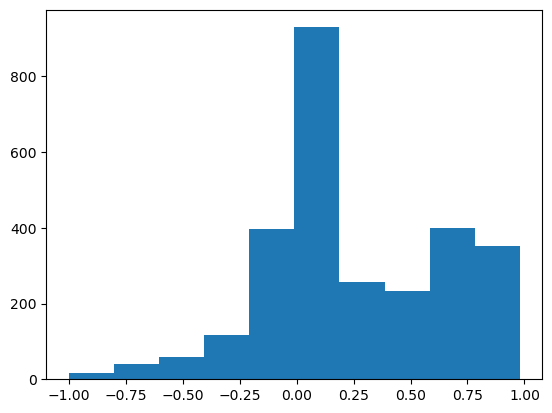

In [34]:
plt.hist(delta_df['delta'])

### **phi sum calculation**

In [57]:
# completeness property phi matrix --> (15, 56, 25, 144, 73, 6)
phi_data = []
# going thru each run batch (folder)
for r in range(completeness_property_phi_matrix.shape[0]):
    #print(f"processing run index {r}")
#r=0
# going thru each file in run batch
    for f in range(completeness_property_phi_matrix.shape[1]):
        #print(f"  -> processing file index {f}")

        # going thru each sample in file 
        for s in range(completeness_property_phi_matrix.shape[2]):
            #print(f"    -> processing sample index {s}")
            
            # sum over lat, lon, vars
            # phi_val = np.sum(completeness_property_phi_matrix, axis=(3,4,5))
            phi_val = np.sum(completeness_property_phi_matrix[r, f, s]) # slice instead to 
            

            # append to make df 
            phi_data.append({
                'id': f"{r}_{f}_{s}",
                'phi': (phi_val.as_int)
            })

phi_df = pd.DataFrame(phi_data)

AttributeError: 'numpy.float32' object has no attribute 'as_int'

In [56]:
plt.hist(phi_data['phi'])

TypeError: list indices must be integers or slices, not str

In [36]:
phi_df

,id,phi
0,0_0_0,0.352448
1,0_0_1,0.165370
2,0_0_2,0.227233
3,0_0_3,0.450227
4,0_0_4,0.366350
...,...,...
2795,1_55_20,-0.083725
2796,1_55_21,-0.160996
2797,1_55_22,-0.188187
2798,1_55_23,0.184347


In [53]:
delta_df

,id,delta
0,0_0_0,0.352388
1,0_0_1,0.169450
2,0_0_2,0.225112
3,0_0_3,0.443845
4,0_0_4,0.367583
...,...,...
2795,1_55_20,0.085406
2796,1_55_21,-0.091799
2797,1_55_22,-0.029486
2798,1_55_23,0.387840


In [37]:
merged = pd.merge(delta_df, phi_df, on='id')

In [38]:
print(f"Delta length: {len(delta_df)}")
print(f"Phi length: {len(phi_df)}")
print(f"Merged length: {len(merged)}")

Delta length: 2800
Phi length: 2800
Merged length: 2800


In [39]:
merged

,id,delta,phi
0,0_0_0,0.352388,0.352448
1,0_0_1,0.169450,0.165370
2,0_0_2,0.225112,0.227233
3,0_0_3,0.443845,0.450227
4,0_0_4,0.367583,0.366350
...,...,...,...
2795,1_55_20,0.085406,-0.083725
2796,1_55_21,-0.091799,-0.160996
2797,1_55_22,-0.029486,-0.188187
2798,1_55_23,0.387840,0.184347


In [40]:
len(merged['phi']) # 1 by 56 by 25

2800

In [41]:
merged['phi'][0]

0.35244784

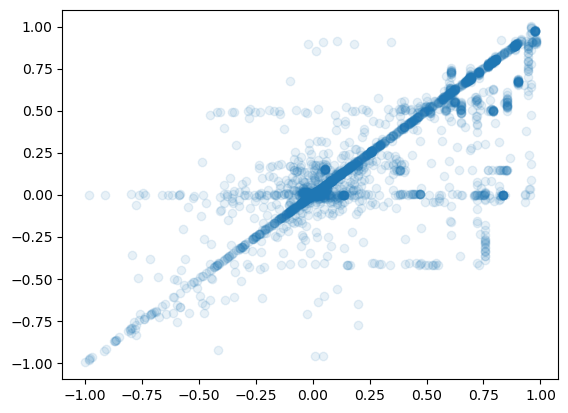

In [42]:
# 4. Now the scatter plot will be aligned regardless of processing order
plt.scatter(merged['delta'], merged['phi'], alpha=0.1)

**horizontal line** = no change in phi sum (0) but changes in pred delta --> vanishing gradient issue
    - because this is where the early & late years are super different so pred delta has values, but IG did not track feature importance bc vanishing gradient (?)

**vertical line at delta value of 0.00** = no change in pred delta (0) but changes in phi sum --> similar climate scenarios
    - predicted close to early period, causing 0.0 pred delta but IG picked up on feature differences (internal noise that IG picked up on?)

**vertical line at delta value of 1.00** = no change in pred delta (1) but changes in phi sum --> super different climate scenarios
    - delta pred perfectly predicted 1.0 (late period), but IG did not pick up on the same amount of feature importance bc jump was too big? 


In [43]:
merged

,id,delta,phi
0,0_0_0,0.352388,0.352448
1,0_0_1,0.169450,0.165370
2,0_0_2,0.225112,0.227233
3,0_0_3,0.443845,0.450227
4,0_0_4,0.367583,0.366350
...,...,...,...
2795,1_55_20,0.085406,-0.083725
2796,1_55_21,-0.091799,-0.160996
2797,1_55_22,-0.029486,-0.188187
2798,1_55_23,0.387840,0.184347


In [44]:
# looking at absolute error btwn delta and phi
merged['abs_error'] = (merged['delta'] - merged['phi']).abs()

sorted_df = merged.sort_values(by='abs_error', ascending=False)

sorted_df.head(10)

,id,delta,phi,abs_error
2202,1_32_2,0.728346,-0.417583,1.145929
2224,1_32_24,0.757134,-0.386492,1.143625
2162,1_30_12,0.719471,-0.405535,1.125006
2212,1_32_12,0.757120,-0.367748,1.124867
2217,1_32_17,0.757134,-0.364281,1.121415
2207,1_32_7,0.757069,-0.338576,1.095644
2215,1_32_15,0.757134,-0.337826,1.094960
2219,1_32_19,0.757103,-0.332604,1.089707
2216,1_32_16,0.757134,-0.319004,1.076137
2211,1_32_11,0.757113,-0.312301,1.069414


In [54]:
sorted_df

,id,delta,phi,abs_error
2202,1_32_2,0.728346,-0.417583,1.145929
2224,1_32_24,0.757134,-0.386492,1.143625
2162,1_30_12,0.719471,-0.405535,1.125006
2212,1_32_12,0.757120,-0.367748,1.124867
2217,1_32_17,0.757134,-0.364281,1.121415
...,...,...,...,...
241,0_9_16,0.000000,0.000000,0.000000
242,0_9_17,0.000000,0.000000,0.000000
244,0_9_19,0.000000,0.000000,0.000000
245,0_9_20,0.000000,0.000000,0.000000


In [45]:
from sklearn.metrics import r2_score, mean_absolute_error

# calculating r2 and mae from scikit-learn
r2 = r2_score(merged['delta'], merged['phi'])
mae = mean_absolute_error(merged['delta'], merged['phi'])

print(f"r squared value: {r2:.4f}")
print(f"MAE: {mae:.4f}")

r squared value: 0.6263
MAE: 0.1103


In [46]:
# threshold
epsilon = 0.05

# delta (x axis) close to 0 ish 
is_delta_zero = merged['delta'].abs() < epsilon

# look where phi is not 0 --> aka where the 1:1 points are 
is_phi_not_zero = merged['phi'].abs() > epsilon

# filter out merged df 
vertical_line_0 = merged[is_delta_zero & is_phi_not_zero]

vertical_line_0.head(10)

,id,delta,phi,abs_error
454,0_18_4,0.048843,0.050480,0.001637
1409,1_0_9,0.008558,-0.414741,0.423300
1458,1_2_8,-0.023551,0.484155,0.507706
1474,1_2_24,-0.033215,0.491987,0.525202
1475,1_3_0,-0.014703,0.306245,0.320948
1500,1_4_0,0.022026,0.509713,0.487687
1575,1_7_0,-0.046710,-0.171056,0.124346
1578,1_7_3,-0.047290,-0.239294,0.192005
1581,1_7_6,-0.030362,-0.081428,0.051066
1586,1_7_11,-0.044444,-0.404529,0.360086


In [47]:
# threshold
epsilon = 0.05

# delta (x axis) close to 1 ish 
is_delta_one = (merged['delta']-1.0).abs() < epsilon

# look where phi is not 1 --> aka where the 1:1 points are 
is_phi_not_one = merged['phi']< (1-epsilon)

# filter out merged df 
vertical_line_1 = merged[is_delta_one & is_phi_not_one]

vertical_line_1.head(10)

,id,delta,phi,abs_error
2702,1_52_2,0.965588,0.906760,0.058829
2703,1_52_3,0.973963,0.917730,0.056233
2706,1_52_6,0.964593,0.907505,0.057088
2708,1_52_8,0.979289,0.908292,0.070998
2709,1_52_9,0.979598,0.919683,0.059914
2710,1_52_10,0.963909,0.907980,0.055929
2711,1_52_11,0.964533,0.909944,0.054589
2712,1_52_12,0.979598,0.916133,0.063465
2714,1_52_14,0.979598,0.905869,0.073729
2715,1_52_15,0.979598,0.902833,0.076764


In [48]:
# threshold
epsilon = 0.05

# phi (y axis) close to 0 ish 
is_phi_zero = merged['phi'].abs() < epsilon

# look where delta is not 0 --> aka where the 1:1 points are 
is_delta_not_zero = merged['delta'].abs() > epsilon

# filter out merged df 
horizontal_line_0 = merged[is_delta_zero & is_phi_not_zero]

horizontal_line_0.head(10)

,id,delta,phi,abs_error
454,0_18_4,0.048843,0.050480,0.001637
1409,1_0_9,0.008558,-0.414741,0.423300
1458,1_2_8,-0.023551,0.484155,0.507706
1474,1_2_24,-0.033215,0.491987,0.525202
1475,1_3_0,-0.014703,0.306245,0.320948
1500,1_4_0,0.022026,0.509713,0.487687
1575,1_7_0,-0.046710,-0.171056,0.124346
1578,1_7_3,-0.047290,-0.239294,0.192005
1581,1_7_6,-0.030362,-0.081428,0.051066
1586,1_7_11,-0.044444,-0.404529,0.360086


In [49]:
# 1. Isolate the Vertical Line (Phi Sum is ~0)
# We use a small threshold (1e-6) because floating point math rarely hits exactly 0.0
vertical_line_samples = merged[merged['phi'].abs() < 1e-6]

# 2. Isolate the Horizontal Line (Delta is ~0)
horizontal_line_samples = merged[merged['delta'].abs() < 1e-6]

# 3. Print a summary to see if they share common traits
print(f"Number of samples in Vertical Line: {len(vertical_line_samples)}")
print(f"Number of samples in Horizontal Line: {len(horizontal_line_samples)}")

# Optional: Inspect the first few to see if they are from the same Run/File
print("Sample of vertical line data:")
print(vertical_line_samples.head())

Number of samples in Vertical Line: 16
Number of samples in Horizontal Line: 16
Sample of vertical line data:
        id  delta  phi  abs_error
225  0_9_0    0.0  0.0        0.0
228  0_9_3    0.0  0.0        0.0
229  0_9_4    0.0  0.0        0.0
231  0_9_6    0.0  0.0        0.0
232  0_9_7    0.0  0.0        0.0


In [50]:
vertical_line_samples

,id,delta,phi,abs_error
225,0_9_0,0.0,0.0,0.0
228,0_9_3,0.0,0.0,0.0
229,0_9_4,0.0,0.0,0.0
231,0_9_6,0.0,0.0,0.0
232,0_9_7,0.0,0.0,0.0
234,0_9_9,0.0,0.0,0.0
235,0_9_10,0.0,0.0,0.0
236,0_9_11,0.0,0.0,0.0
237,0_9_12,0.0,0.0,0.0
239,0_9_14,0.0,0.0,0.0


In [51]:
horizontal_line_samples

,id,delta,phi,abs_error
225,0_9_0,0.0,0.0,0.0
228,0_9_3,0.0,0.0,0.0
229,0_9_4,0.0,0.0,0.0
231,0_9_6,0.0,0.0,0.0
232,0_9_7,0.0,0.0,0.0
234,0_9_9,0.0,0.0,0.0
235,0_9_10,0.0,0.0,0.0
236,0_9_11,0.0,0.0,0.0
237,0_9_12,0.0,0.0,0.0
239,0_9_14,0.0,0.0,0.0
